In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
base_path = Path("..")

processed_path = base_path / "data" / "processed"

pred = pd.read_csv(processed_path / "monthly_predictions.csv")

pred["date"] = pd.to_datetime(pred["date"])

pred.head()

,date,month,ticker,mom_1m,mom_3m,mom_6m,vol_1m,vol_3m,vol_6m,volume_ratio,fwd_ret_1m,pred_ret
0,2020-07-31,2020-07,AKAM,0.057463,0.172961,0.204499,0.021498,0.019408,0.029423,0.620392,0.035486,0.013024
1,2020-07-31,2020-07,CHKP,0.161509,0.229042,0.096579,0.016451,0.015150,0.027215,1.186718,0.007260,-0.000977
2,2020-07-31,2020-07,CRWD,0.099563,0.635602,0.853004,0.037055,0.034493,0.045386,0.434706,0.110689,0.050410
3,2020-07-31,2020-07,CSCO,0.030634,0.160094,0.042443,0.013144,0.019398,0.033450,0.779323,-0.103609,0.015954
4,2020-07-31,2020-07,CYBR,0.145301,0.222914,-0.147508,0.024731,0.029831,0.040405,0.711850,-0.062288,0.045840


In [3]:
pred = pred.sort_values(["date","pred_ret"], ascending=[True,False])

Top 5 strategy

In [4]:
top_n = 5

portfolio = pred.groupby("date").head(top_n).copy()

portfolio["weight"] = 1 / top_n

portfolio.head()

,date,month,ticker,mom_1m,mom_3m,mom_6m,vol_1m,vol_3m,vol_6m,volume_ratio,fwd_ret_1m,pred_ret,weight
16,2020-07-31,2020-07,ZS,0.164470,0.942409,1.315030,0.029620,0.047693,0.047996,0.479028,0.103889,0.075713,0.2
7,2020-07-31,2020-07,NET,0.126997,0.822242,1.330347,0.035408,0.043279,0.048477,0.925433,-0.080730,0.068999,0.2
5,2020-07-31,2020-07,FTNT,-0.006608,0.325474,0.198856,0.033307,0.037652,0.043687,0.504895,-0.045481,0.065197,0.2
15,2020-07-31,2020-07,TENB,0.125747,0.359375,0.245138,0.054156,0.035735,0.040696,3.338032,0.109343,0.058566,0.2
2,2020-07-31,2020-07,CRWD,0.099563,0.635602,0.853004,0.037055,0.034493,0.045386,0.434706,0.110689,0.050410,0.2


In [5]:
portfolio["strategy_ret"] = portfolio["weight"] * portfolio["fwd_ret_1m"]

monthly_ret = portfolio.groupby("date")["strategy_ret"].sum().reset_index()

monthly_ret.head()

,date,strategy_ret
0,2020-07-31,0.039542
1,2020-08-31,0.010733
2,2020-09-30,0.040397
3,2020-10-30,0.176966
4,2020-11-30,0.286496


In [6]:
monthly_ret["cum_return"] = (1 + monthly_ret["strategy_ret"]).cumprod()

monthly_ret.head()

,date,strategy_ret,cum_return
0,2020-07-31,0.039542,1.039542
1,2020-08-31,0.010733,1.050699
2,2020-09-30,0.040397,1.093144
3,2020-10-30,0.176966,1.286593
4,2020-11-30,0.286496,1.655196


In [7]:
chart_path = base_path / "outputs" / "charts"
chart_path.mkdir(parents=True, exist_ok=True)

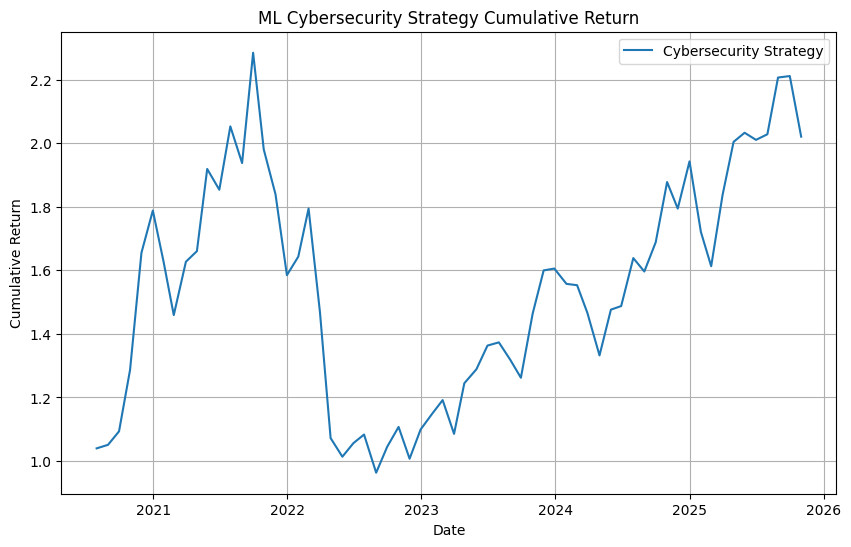

In [8]:
plt.figure(figsize=(10,6))

plt.plot(monthly_ret["date"], monthly_ret["cum_return"], label="Cybersecurity Strategy")

plt.title("ML Cybersecurity Strategy Cumulative Return")

plt.xlabel("Date")
plt.ylabel("Cumulative Return")

plt.legend()
plt.grid(True)

plt.savefig(chart_path / "strategy_cumulative_return.png")

plt.show()

In [9]:
annual_return = (1 + monthly_ret["strategy_ret"].mean())**12 - 1

annual_vol = monthly_ret["strategy_ret"].std() * np.sqrt(12)

sharpe = annual_return / annual_vol

max_drawdown = ((monthly_ret["cum_return"] / monthly_ret["cum_return"].cummax()) - 1).min()

summary = pd.DataFrame({
    "metric":["Annual Return","Annual Volatility","Sharpe Ratio","Max Drawdown"],
    "value":[annual_return,annual_vol,sharpe,max_drawdown]
})

summary

,metric,value
0,Annual Return,0.207682
1,Annual Volatility,0.340928
2,Sharpe Ratio,0.609166
3,Max Drawdown,-0.578638


In [10]:
annual_return = (1 + monthly_ret["strategy_ret"].mean())**12 - 1

annual_vol = monthly_ret["strategy_ret"].std() * np.sqrt(12)

sharpe = annual_return / annual_vol

max_drawdown = ((monthly_ret["cum_return"] / monthly_ret["cum_return"].cummax()) - 1).min()

summary = pd.DataFrame({
    "metric":["Annual Return","Annual Volatility","Sharpe Ratio","Max Drawdown"],
    "value":[annual_return,annual_vol,sharpe,max_drawdown]
})

summary

,metric,value
0,Annual Return,0.207682
1,Annual Volatility,0.340928
2,Sharpe Ratio,0.609166
3,Max Drawdown,-0.578638


In [11]:
table_path = base_path / "outputs" / "tables"
table_path.mkdir(parents=True, exist_ok=True)

summary.to_csv(table_path / "strategy_metrics.csv",index=False)

print("Saved performance metrics.")

Saved performance metrics.


In [12]:
import yfinance as yf

In [16]:
spy.columns

MultiIndex([(  'Date',    ''),
            ( 'Close', 'SPY'),
            (  'High', 'SPY'),
            (   'Low', 'SPY'),
            (  'Open', 'SPY'),
            ('Volume', 'SPY')],
           names=['Price', 'Ticker'])

In [17]:
spy = yf.download(
    "SPY",
    start=monthly_ret["date"].min(),
    end=monthly_ret["date"].max()
)

spy = spy.reset_index()

# 用 Close 计算收益
spy["ret"] = spy["Close"].pct_change()

spy["month"] = spy["Date"].dt.to_period("M")

spy_month = spy.groupby("month").tail(1).copy()

spy_month["ret"] = spy_month["Close"].pct_change()

spy_month["cum"] = (1 + spy_month["ret"]).cumprod()

spy_month.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume,ret,month,cum
Ticker,,SPY,SPY,SPY,SPY,SPY,,,
0,2020-07-31,302.294891,302.396745,297.489944,301.720895,84986800,NaN,2020-07,NaN
21,2020-08-31,323.394043,325.236392,323.162591,324.356891,66099200,NaN,2020-08,NaN
42,2020-09-30,311.284973,314.445315,309.416641,309.611831,104081100,NaN,2020-09,NaN
64,2020-10-30,303.523590,306.451554,299.861302,305.140936,120287300,NaN,2020-10,NaN
84,2020-11-30,336.539886,337.525169,333.853605,337.255602,83872700,NaN,2020-11,NaN


In [21]:
spy.columns = [col[0] if isinstance(col, tuple) else col for col in spy.columns]
spy_month.columns = [col[0] if isinstance(col, tuple) else col for col in spy_month.columns]

print(spy.columns)
print(spy_month.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'ret', 'month'], dtype='object')
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'ret', 'month',
       'cum'],
      dtype='object')


In [22]:
monthly_ret["month"] = monthly_ret["date"].dt.to_period("M").astype(str)
spy_month["month"] = pd.to_datetime(spy_month["Date"]).dt.to_period("M").astype(str)

merged = pd.merge(
    monthly_ret,
    spy_month[["month", "cum"]],
    on="month",
    how="left"
)

merged = merged.rename(columns={"cum": "spy_cum"})

merged.head()

,date,strategy_ret,cum_return,month,spy_cum
0,2020-07-31,0.039542,1.039542,2020-07,NaN
1,2020-08-31,0.010733,1.050699,2020-08,NaN
2,2020-09-30,0.040397,1.093144,2020-09,NaN
3,2020-10-30,0.176966,1.286593,2020-10,NaN
4,2020-11-30,0.286496,1.655196,2020-11,NaN


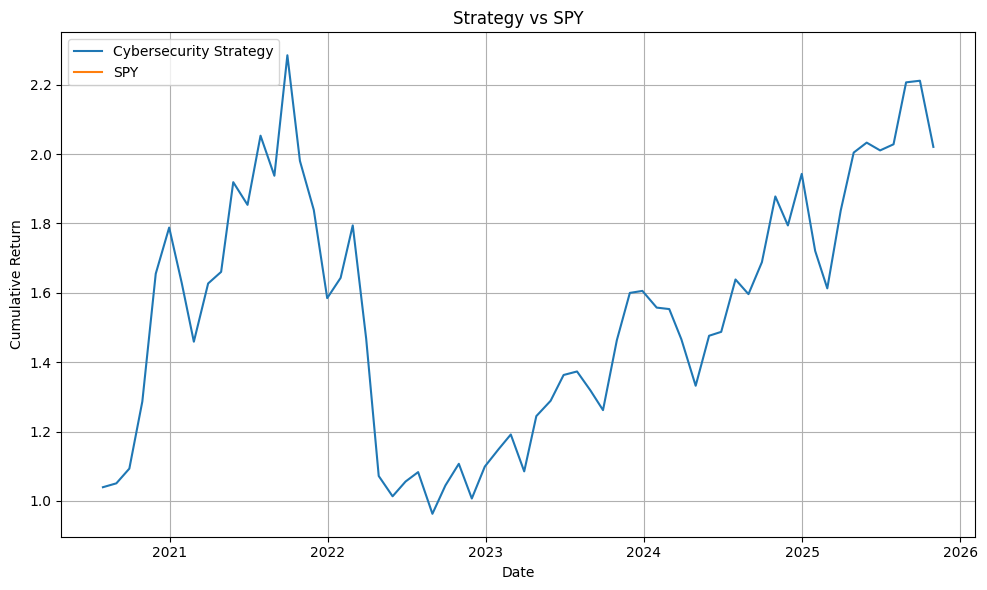

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(merged["date"], merged["cum_return"], label="Cybersecurity Strategy")
plt.plot(merged["date"], merged["spy_cum"], label="SPY")

plt.title("Strategy vs SPY")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(chart_path / "strategy_vs_spy.png")
plt.show()

In [25]:
merged[["date", "month", "cum_return", "spy_cum"]].head(15)

,date,month,cum_return,spy_cum
0,2020-07-31,2020-07,1.039542,NaN
1,2020-08-31,2020-08,1.050699,NaN
2,2020-09-30,2020-09,1.093144,NaN
3,2020-10-30,2020-10,1.286593,NaN
4,2020-11-30,2020-11,1.655196,NaN
5,2020-12-31,2020-12,1.788285,NaN
6,2021-01-29,2021-01,1.628596,NaN
7,2021-02-26,2021-02,1.459151,NaN
8,2021-03-31,2021-03,1.627055,NaN
9,2021-04-30,2021-04,1.660488,NaN


## Clean Benchmark Construction

In [26]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 下载 SPY 日频数据
spy = yf.download(
    "SPY",
    start=monthly_ret["date"].min() - pd.DateOffset(days=10),
    end=monthly_ret["date"].max() + pd.DateOffset(days=10),
    auto_adjust=False,
    progress=False
)

spy = spy.reset_index()

# 拍平列名，防止 MultiIndex 干扰
spy.columns = [col[0] if isinstance(col, tuple) else col for col in spy.columns]

# 日期处理
spy["Date"] = pd.to_datetime(spy["Date"])
spy = spy.sort_values("Date")

# 转成月度：取每个月最后一个交易日
spy["month"] = spy["Date"].dt.to_period("M").astype(str)
spy_month = spy.groupby("month").tail(1).copy()

# 用月末 Close 算 benchmark 月收益
spy_month["spy_ret"] = spy_month["Close"].pct_change()
spy_month["spy_cum"] = (1 + spy_month["spy_ret"].fillna(0)).cumprod()

# 只保留需要的列
spy_month = spy_month[["month", "Date", "Close", "spy_ret", "spy_cum"]].copy()

spy_month.head(12)

,month,Date,Close,spy_ret,spy_cum
8,2020-07,2020-07-31,326.519989,NaN,1.000000
29,2020-08,2020-08-31,349.309998,0.069797,1.069797
50,2020-09,2020-09-30,334.890015,-0.041281,1.025634
72,2020-10,2020-10-30,326.540009,-0.024934,1.000061
92,2020-11,2020-11-30,362.059998,0.108777,1.108845
114,2020-12,2020-12-31,373.880005,0.032647,1.145045
133,2021-01,2021-01-29,370.070007,-0.010190,1.133376
152,2021-02,2021-02-26,380.359985,0.027805,1.164890
175,2021-03,2021-03-31,396.329987,0.041987,1.213800
196,2021-04,2021-04-30,417.299988,0.052910,1.278023


In [27]:
print(monthly_ret["date"].head())
monthly_ret["month"] = monthly_ret["date"].dt.to_period("M").astype(str)

print(monthly_ret["month"].head(10).tolist())
print(spy_month["month"].head(10).tolist())
print("monthly_ret months:", monthly_ret["month"].nunique())
print("spy_month months:", spy_month["month"].nunique())

0   2020-07-31
1   2020-08-31
2   2020-09-30
3   2020-10-30
4   2020-11-30
Name: date, dtype: datetime64[ns]
['2020-07', '2020-08', '2020-09', '2020-10', '2020-11', '2020-12', '2021-01', '2021-02', '2021-03', '2021-04']
['2020-07', '2020-08', '2020-09', '2020-10', '2020-11', '2020-12', '2021-01', '2021-02', '2021-03', '2021-04']
monthly_ret months: 64
spy_month months: 65


In [28]:
merged = pd.merge(
    monthly_ret,
    spy_month[["month", "spy_cum"]],
    on="month",
    how="left",
    validate="one_to_one"
)

merged[["date", "month", "cum_return", "spy_cum"]].head(15)

,date,month,cum_return,spy_cum
0,2020-07-31,2020-07,1.039542,1.000000
1,2020-08-31,2020-08,1.050699,1.069797
2,2020-09-30,2020-09,1.093144,1.025634
3,2020-10-30,2020-10,1.286593,1.000061
4,2020-11-30,2020-11,1.655196,1.108845
5,2020-12-31,2020-12,1.788285,1.145045
6,2021-01-29,2021-01,1.628596,1.133376
7,2021-02-26,2021-02,1.459151,1.164890
8,2021-03-31,2021-03,1.627055,1.213800
9,2021-04-30,2021-04,1.660488,1.278023


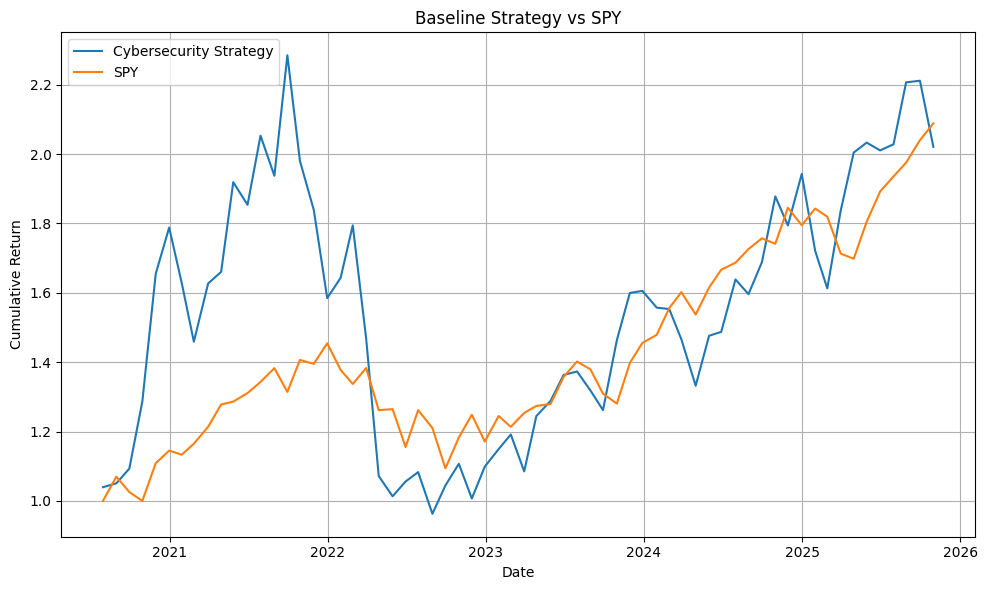

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(merged["date"], merged["cum_return"], label="Cybersecurity Strategy")
plt.plot(merged["date"], merged["spy_cum"], label="SPY")

plt.title("Baseline Strategy vs SPY")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(chart_path / "baseline_strategy_vs_spy.png")
plt.show()

## Risk-Controlled Portfolio Construction

In [30]:
pred_rc = pred.copy()

# 只保留正预测收益
pred_rc = pred_rc[pred_rc["pred_ret"] > 0].copy()

# 每个月剔除波动率最高的20%
def remove_high_vol(group):
    cutoff = group["vol_3m"].quantile(0.8)
    return group[group["vol_3m"] <= cutoff]

pred_rc = pred_rc.groupby("date", group_keys=False).apply(remove_high_vol).reset_index(drop=True)

# 每个月最多保留前6只
top_n = 6
portfolio_rc = pred_rc.sort_values(["date", "pred_ret"], ascending=[True, False]).groupby("date").head(top_n).copy()

portfolio_rc.head()

C:\Users\nch\AppData\Local\Temp\ipykernel_11744\1225388376.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pred_rc = pred_rc.groupby("date", group_keys=False).apply(remove_high_vol).reset_index(drop=True)


,date,month,ticker,mom_1m,mom_3m,mom_6m,vol_1m,vol_3m,vol_6m,volume_ratio,fwd_ret_1m,pred_ret
0,2020-07-31,2020-07,TENB,0.125747,0.359375,0.245138,0.054156,0.035735,0.040696,3.338032,0.109343,0.058566
1,2020-07-31,2020-07,CRWD,0.099563,0.635602,0.853004,0.037055,0.034493,0.045386,0.434706,0.110689,0.050410
2,2020-07-31,2020-07,CYBR,0.145301,0.222914,-0.147508,0.024731,0.029831,0.040405,0.711850,-0.062288,0.045840
3,2020-07-31,2020-07,NTGR,0.261280,0.400911,0.195568,0.031144,0.030190,0.041680,1.296451,0.084553,0.043164
4,2020-07-31,2020-07,RPD,0.126726,0.343482,0.003200,0.025280,0.026100,0.038459,0.551401,0.083935,0.031893


In [31]:
portfolio_rc["risk_adj_score"] = portfolio_rc["pred_ret"] / portfolio_rc["vol_3m"].replace(0, np.nan)
portfolio_rc = portfolio_rc.replace([np.inf, -np.inf], np.nan).dropna(subset=["risk_adj_score"]).copy()
portfolio_rc["risk_adj_score"] = portfolio_rc["risk_adj_score"].clip(lower=0)

In [32]:
def cap_and_normalize(group, cap=0.25):
    scores = group["risk_adj_score"].values

    if scores.sum() <= 0:
        weights = np.repeat(1 / len(group), len(group))
    else:
        weights = scores / scores.sum()
        weights = np.minimum(weights, cap)
        weights = weights / weights.sum()

    group = group.copy()
    group["weight"] = weights
    return group

portfolio_rc = portfolio_rc.groupby("date", group_keys=False).apply(cap_and_normalize).reset_index(drop=True)

portfolio_rc[["date", "ticker", "pred_ret", "vol_3m", "risk_adj_score", "weight"]].head(15)

C:\Users\nch\AppData\Local\Temp\ipykernel_11744\403072351.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  portfolio_rc = portfolio_rc.groupby("date", group_keys=False).apply(cap_and_normalize).reset_index(drop=True)


,date,ticker,pred_ret,vol_3m,risk_adj_score,weight
0,2020-07-31,TENB,0.058566,0.035735,1.638873,0.193401
1,2020-07-31,CRWD,0.050410,0.034493,1.461458,0.172464
2,2020-07-31,CYBR,0.045840,0.029831,1.536652,0.181338
3,2020-07-31,NTGR,0.043164,0.030190,1.429753,0.168723
4,2020-07-31,RPD,0.031893,0.026100,1.221937,0.144199
5,2020-07-31,GEN,0.030418,0.025663,1.185294,0.139875
6,2020-08-31,FTNT,0.041775,0.025926,1.611336,0.207809
7,2020-08-31,OKTA,0.037037,0.028062,1.319821,0.170213
8,2020-08-31,ZS,0.036544,0.028201,1.295848,0.167122
9,2020-08-31,NTGR,0.036125,0.028622,1.262171,0.162778


In [33]:
portfolio_rc["gross_weighted_ret"] = portfolio_rc["weight"] * portfolio_rc["fwd_ret_1m"]

monthly_rc = portfolio_rc.groupby("date").agg(
    gross_ret=("gross_weighted_ret", "sum")
).reset_index()

monthly_rc["gross_cum_return"] = (1 + monthly_rc["gross_ret"]).cumprod()

monthly_rc.head()

,date,gross_ret,gross_cum_return
0,2020-07-31,0.069661,1.069661
1,2020-08-31,-0.059321,1.006207
2,2020-09-30,0.003688,1.009918
3,2020-10-30,0.086503,1.097278
4,2020-11-30,0.237798,1.358208


In [34]:
weights_wide = portfolio_rc.pivot_table(
    index="date",
    columns="ticker",
    values="weight",
    fill_value=0
).sort_index()

turnover = weights_wide.diff().abs().sum(axis=1)
turnover.iloc[0] = weights_wide.iloc[0].sum()

turnover = turnover.reset_index()
turnover.columns = ["date", "turnover"]

monthly_rc = monthly_rc.merge(turnover, on="date", how="left")

transaction_cost_rate = 0.002
monthly_rc["tcost"] = monthly_rc["turnover"] * transaction_cost_rate

monthly_rc["net_ret"] = monthly_rc["gross_ret"] - monthly_rc["tcost"]
monthly_rc["net_cum_return"] = (1 + monthly_rc["net_ret"]).cumprod()

monthly_rc.head()

,date,gross_ret,gross_cum_return,turnover,tcost,net_ret,net_cum_return
0,2020-07-31,0.069661,1.069661,1.000000,0.002000,0.067661,1.067661
1,2020-08-31,-0.059321,1.006207,1.348001,0.002696,-0.062017,1.001447
2,2020-09-30,0.003688,1.009918,0.172490,0.000345,0.003343,1.004795
3,2020-10-30,0.086503,1.097278,0.667184,0.001334,0.085168,1.090371
4,2020-11-30,0.237798,1.358208,0.717854,0.001436,0.236362,1.348094


In [35]:
def compute_metrics(ret_series, cum_series):
    annual_return = (1 + ret_series.mean()) ** 12 - 1
    annual_vol = ret_series.std() * np.sqrt(12)
    sharpe = annual_return / annual_vol if annual_vol != 0 else np.nan

    downside = ret_series[ret_series < 0].std() * np.sqrt(12)
    sortino = annual_return / downside if pd.notna(downside) and downside != 0 else np.nan

    max_drawdown = (cum_series / cum_series.cummax() - 1).min()

    return annual_return, annual_vol, sharpe, sortino, max_drawdown

baseline_metrics = compute_metrics(monthly_ret["strategy_ret"], monthly_ret["cum_return"])
rc_gross_metrics = compute_metrics(monthly_rc["gross_ret"], monthly_rc["gross_cum_return"])
rc_net_metrics = compute_metrics(monthly_rc["net_ret"], monthly_rc["net_cum_return"])

comparison = pd.DataFrame({
    "metric": ["Annual Return", "Annual Volatility", "Sharpe Ratio", "Sortino Ratio", "Max Drawdown"],
    "baseline": baseline_metrics,
    "risk_controlled_gross": rc_gross_metrics,
    "risk_controlled_net": rc_net_metrics
})

comparison

,metric,baseline,risk_controlled_gross,risk_controlled_net
0,Annual Return,0.207682,0.137703,0.115400
1,Annual Volatility,0.340928,0.261895,0.262339
2,Sharpe Ratio,0.609166,0.525795,0.439888
3,Sortino Ratio,1.035374,1.090432,0.866194
4,Max Drawdown,-0.578638,-0.322455,-0.337316


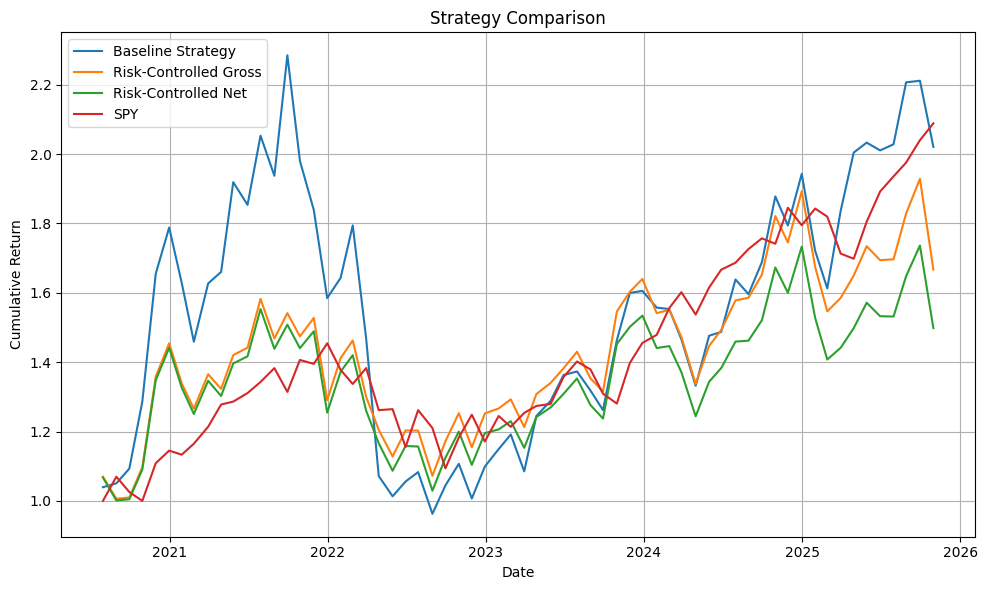

In [36]:
monthly_rc["month"] = monthly_rc["date"].dt.to_period("M").astype(str)

plot_df = pd.merge(
    monthly_rc,
    spy_month[["month", "spy_cum"]],
    on="month",
    how="left"
)

plt.figure(figsize=(10, 6))

plt.plot(monthly_ret["date"], monthly_ret["cum_return"], label="Baseline Strategy")
plt.plot(monthly_rc["date"], monthly_rc["gross_cum_return"], label="Risk-Controlled Gross")
plt.plot(monthly_rc["date"], monthly_rc["net_cum_return"], label="Risk-Controlled Net")
plt.plot(plot_df["date"], plot_df["spy_cum"], label="SPY")

plt.title("Strategy Comparison")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(chart_path / "strategy_comparison.png")
plt.show()

## Optimized Portfolio Construction

In [37]:
from scipy.optimize import minimize

prices = pd.read_csv(processed_path / "prices_clean.csv")
prices["date"] = pd.to_datetime(prices["date"])
prices = prices.sort_values(["ticker", "date"]).reset_index(drop=True)

prices["ret_1d"] = prices.groupby("ticker")["adj_close"].pct_change()

C:\Users\nch\AppData\Local\Temp\ipykernel_11744\335422438.py:7: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  prices["ret_1d"] = prices.groupby("ticker")["adj_close"].pct_change()


In [38]:
from scipy.optimize import minimize

prices = pd.read_csv(processed_path / "prices_clean.csv")
prices["date"] = pd.to_datetime(prices["date"])
prices = prices.sort_values(["ticker", "date"]).reset_index(drop=True)

prices["ret_1d"] = prices.groupby("ticker")["adj_close"].pct_change()

C:\Users\nch\AppData\Local\Temp\ipykernel_11744\335422438.py:7: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  prices["ret_1d"] = prices.groupby("ticker")["adj_close"].pct_change()


In [39]:
pred_opt = pred.copy()

# 只保留正预测收益
pred_opt = pred_opt[pred_opt["pred_ret"] > 0].copy()

# 每个月剔除波动率最高的20%
def remove_high_vol(group):
    cutoff = group["vol_3m"].quantile(0.8)
    return group[group["vol_3m"] <= cutoff]

pred_opt = pred_opt.groupby("date", group_keys=False).apply(remove_high_vol).reset_index(drop=True)

# 每个月保留前6只
top_n = 6
pred_opt = pred_opt.sort_values(["date", "pred_ret"], ascending=[True, False]).groupby("date").head(top_n).copy()

pred_opt.head()

C:\Users\nch\AppData\Local\Temp\ipykernel_11744\923547264.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pred_opt = pred_opt.groupby("date", group_keys=False).apply(remove_high_vol).reset_index(drop=True)


,date,month,ticker,mom_1m,mom_3m,mom_6m,vol_1m,vol_3m,vol_6m,volume_ratio,fwd_ret_1m,pred_ret
0,2020-07-31,2020-07,TENB,0.125747,0.359375,0.245138,0.054156,0.035735,0.040696,3.338032,0.109343,0.058566
1,2020-07-31,2020-07,CRWD,0.099563,0.635602,0.853004,0.037055,0.034493,0.045386,0.434706,0.110689,0.050410
2,2020-07-31,2020-07,CYBR,0.145301,0.222914,-0.147508,0.024731,0.029831,0.040405,0.711850,-0.062288,0.045840
3,2020-07-31,2020-07,NTGR,0.261280,0.400911,0.195568,0.031144,0.030190,0.041680,1.296451,0.084553,0.043164
4,2020-07-31,2020-07,RPD,0.126726,0.343482,0.003200,0.025280,0.026100,0.038459,0.551401,0.083935,0.031893


In [41]:
def optimize_weights(mu, cov, cap=0.30):
    n = len(mu)

    # 如果股票太少，直接等权
    if n == 0:
        return np.array([])
    if n == 1:
        return np.array([1.0])

    def neg_sharpe(w, mu, cov):
        port_ret = np.dot(w, mu)
        port_vol = np.sqrt(np.dot(w.T, np.dot(cov, w)))
        if port_vol == 0:
            return 1e6
        return -port_ret / port_vol

    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1}
    ]

    bounds = [(0, cap) for _ in range(n)]

    x0 = np.repeat(1 / n, n)

    result = minimize(
        neg_sharpe,
        x0=x0,
        args=(mu, cov),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if result.success:
        return result.x
    else:
        return x0

In [42]:
opt_results = []

candidate_dates = sorted(pred_opt["date"].unique())

for dt in candidate_dates:
    current = pred_opt[pred_opt["date"] == dt].copy()
    tickers = current["ticker"].tolist()

    if len(tickers) == 0:
        continue

    # 取过去252个交易日数据估计协方差
    hist = prices[(prices["date"] < dt) & (prices["ticker"].isin(tickers))].copy()

    # 只保留最近252个交易日
    hist = hist.sort_values("date")
    hist = hist.groupby("ticker").tail(252)

    ret_matrix = hist.pivot_table(index="date", columns="ticker", values="ret_1d")

    # 如果历史数据太少，跳过
    if ret_matrix.shape[0] < 60:
        continue

    # 缺失值处理：太激进会有偏差，这里先用前向/后向填充
    ret_matrix = ret_matrix.ffill().bfill()

    # 协方差矩阵
    cov = ret_matrix.cov().values

    # 预测收益作为 expected return
    mu_df = current.set_index("ticker").loc[ret_matrix.columns, "pred_ret"]
    mu = mu_df.values

    # 数值稳定性处理
    cov = cov + np.eye(len(mu)) * 1e-6

    weights = optimize_weights(mu, cov, cap=0.30)

    temp = current.set_index("ticker").loc[ret_matrix.columns].reset_index()
    temp["opt_weight"] = weights

    opt_results.append(temp)

portfolio_opt = pd.concat(opt_results, ignore_index=True)
portfolio_opt.head()

,ticker,date,month,mom_1m,mom_3m,mom_6m,vol_1m,vol_3m,vol_6m,volume_ratio,fwd_ret_1m,pred_ret,opt_weight
0,CRWD,2020-07-31,2020-07,0.099563,0.635602,0.853004,0.037055,0.034493,0.045386,0.434706,0.110689,0.050410,0.078666
1,CYBR,2020-07-31,2020-07,0.145301,0.222914,-0.147508,0.024731,0.029831,0.040405,0.711850,-0.062288,0.045840,0.092446
2,GEN,2020-07-31,2020-07,0.084977,0.034168,0.321756,0.016919,0.025663,0.027532,0.668654,0.102588,0.030418,0.300000
3,NTGR,2020-07-31,2020-07,0.261280,0.400911,0.195568,0.031144,0.030190,0.041680,1.296451,0.084553,0.043164,0.228888
4,RPD,2020-07-31,2020-07,0.126726,0.343482,0.003200,0.025280,0.026100,0.038459,0.551401,0.083935,0.031893,0.000000


In [43]:
portfolio_opt["opt_weighted_ret"] = portfolio_opt["opt_weight"] * portfolio_opt["fwd_ret_1m"]

monthly_opt = portfolio_opt.groupby("date").agg(
    opt_ret=("opt_weighted_ret", "sum")
).reset_index()

monthly_opt["opt_cum_return"] = (1 + monthly_opt["opt_ret"]).cumprod()

monthly_opt.head()

,date,opt_ret,opt_cum_return
0,2020-07-31,0.085882,1.085882
1,2020-08-31,-0.063422,1.017013
2,2020-09-30,0.000382,1.017401
3,2020-10-30,0.084992,1.103872
4,2020-11-30,0.232916,1.360981


In [44]:
opt_weights_wide = portfolio_opt.pivot_table(
    index="date",
    columns="ticker",
    values="opt_weight",
    fill_value=0
).sort_index()

opt_turnover = opt_weights_wide.diff().abs().sum(axis=1)
opt_turnover.iloc[0] = opt_weights_wide.iloc[0].sum()

opt_turnover = opt_turnover.reset_index()
opt_turnover.columns = ["date", "turnover"]

monthly_opt = monthly_opt.merge(opt_turnover, on="date", how="left")

transaction_cost_rate = 0.002
monthly_opt["tcost"] = monthly_opt["turnover"] * transaction_cost_rate

monthly_opt["opt_net_ret"] = monthly_opt["opt_ret"] - monthly_opt["tcost"]
monthly_opt["opt_net_cum_return"] = (1 + monthly_opt["opt_net_ret"]).cumprod()

monthly_opt.head()

,date,opt_ret,opt_cum_return,turnover,tcost,opt_net_ret,opt_net_cum_return
0,2020-07-31,0.085882,1.085882,1.000000,0.002000,0.083882,1.083882
1,2020-08-31,-0.063422,1.017013,1.542223,0.003084,-0.066506,1.011797
2,2020-09-30,0.000382,1.017401,0.768523,0.001537,-0.001155,1.010628
3,2020-10-30,0.084992,1.103872,0.368523,0.000737,0.084255,1.095778
4,2020-11-30,0.232916,1.360981,1.117665,0.002235,0.230681,1.348553


In [45]:
opt_gross_metrics = compute_metrics(monthly_opt["opt_ret"], monthly_opt["opt_cum_return"])
opt_net_metrics = compute_metrics(monthly_opt["opt_net_ret"], monthly_opt["opt_net_cum_return"])

comparison2 = pd.DataFrame({
    "metric": ["Annual Return", "Annual Volatility", "Sharpe Ratio", "Sortino Ratio", "Max Drawdown"],
    "baseline": baseline_metrics,
    "risk_controlled_net": rc_net_metrics,
    "optimized_gross": opt_gross_metrics,
    "optimized_net": opt_net_metrics
})

comparison2

,metric,baseline,risk_controlled_net,optimized_gross,optimized_net
0,Annual Return,0.207682,0.115400,0.086455,0.062671
1,Annual Volatility,0.340928,0.262339,0.261421,0.261905
2,Sharpe Ratio,0.609166,0.439888,0.330713,0.239289
3,Sortino Ratio,1.035374,0.866194,0.561235,0.397327
4,Max Drawdown,-0.578638,-0.337316,-0.359424,-0.385620


# Signal IC

In [46]:
ic_series = pred.groupby("date").apply(
    lambda df: df["pred_ret"].corr(df["fwd_ret_1m"])
)

ic_series.head()

C:\Users\nch\AppData\Local\Temp\ipykernel_11744\1235841067.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic_series = pred.groupby("date").apply(


date
2020-07-31    0.095184
2020-08-31    0.542542
2020-09-30    0.335574
2020-10-30    0.291777
2020-11-30    0.382023
dtype: float64

In [47]:
ic_mean = ic_series.mean()
ic_std = ic_series.std()

ic_mean, ic_std

(np.float64(0.008798921058897156), np.float64(0.3590737382455848))

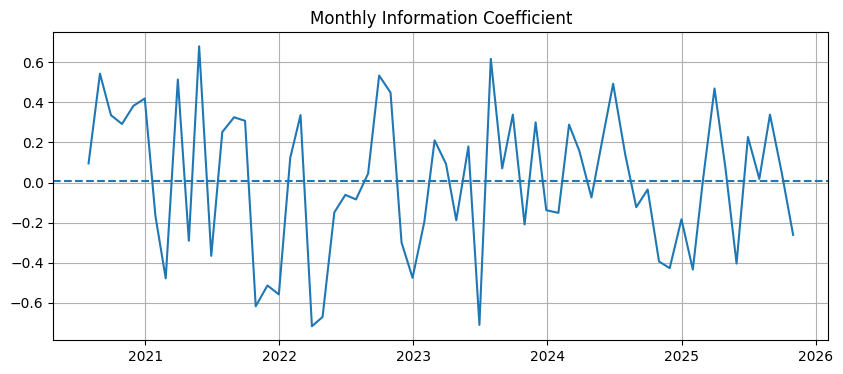

In [48]:
plt.figure(figsize=(10,4))

plt.plot(ic_series.index, ic_series.values)

plt.axhline(ic_mean, linestyle="--")

plt.title("Monthly Information Coefficient")

plt.grid(True)
plt.show()

# Spearman Rank IC

In [49]:
from scipy.stats import spearmanr

rank_ic = pred.groupby("date").apply(
    lambda df: spearmanr(df["pred_ret"], df["fwd_ret_1m"])[0]
)

rank_ic_mean = rank_ic.mean()

rank_ic_mean

C:\Users\nch\AppData\Local\Temp\ipykernel_11744\4095199493.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rank_ic = pred.groupby("date").apply(


np.float64(0.005088606166150672)

t = IC_mean / (IC_std / sqrt(N))

In [50]:
import numpy as np

N = len(ic_series)

ic_tstat = ic_mean / (ic_std / np.sqrt(N))

ic_tstat

np.float64(0.19603596970111412)

# Rank IC

In [51]:
ic_ir = ic_mean / ic_std
ic_ir

np.float64(0.024504496212639264)

In [55]:
ic_summary = pd.DataFrame({
    "metric": ["IC Mean", "IC Std", "IC IR", "IC t-stat", "Rank IC Mean"],
    "value": [ic_mean, ic_std, ic_ir, ic_tstat, rank_ic_mean]
})

ic_summary

,metric,value
0,IC Mean,0.008799
1,IC Std,0.359074
2,IC IR,0.024504
3,IC t-stat,0.196036
4,Rank IC Mean,0.005089


In [56]:
ic_summary.to_csv(table_path / "ic_summary.csv", index=False)
print("Saved IC summary.")

Saved IC summary.


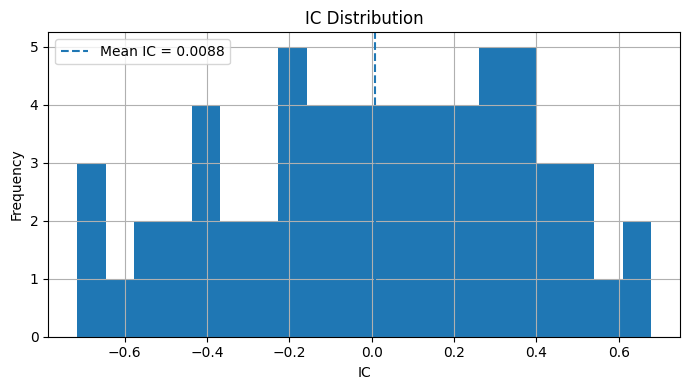

In [57]:
plt.figure(figsize=(7, 4))

plt.hist(ic_series.dropna(), bins=20)
plt.axvline(ic_mean, linestyle="--", label=f"Mean IC = {ic_mean:.4f}")

plt.title("IC Distribution")
plt.xlabel("IC")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(chart_path / "ic_distribution.png")
plt.show()

# Benchmark add : CIBR and HACK

In [58]:
import yfinance as yf

def build_monthly_benchmark(ticker, start_date, end_date):
    df = yf.download(
        ticker,
        start=start_date - pd.DateOffset(days=10),
        end=end_date + pd.DateOffset(days=10),
        auto_adjust=False,
        progress=False
    )

    df = df.reset_index()
    df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date")

    df["month"] = df["Date"].dt.to_period("M").astype(str)
    monthly = df.groupby("month").tail(1).copy()

    monthly[f"{ticker.lower()}_ret"] = monthly["Close"].pct_change()
    monthly[f"{ticker.lower()}_cum"] = (1 + monthly[f"{ticker.lower()}_ret"].fillna(0)).cumprod()

    keep_cols = ["month", "Date", "Close", f"{ticker.lower()}_ret", f"{ticker.lower()}_cum"]
    return monthly[keep_cols].copy()

In [59]:
start_date = monthly_ret["date"].min()
end_date = monthly_ret["date"].max()

spy_month = build_monthly_benchmark("SPY", start_date, end_date)
cibr_month = build_monthly_benchmark("CIBR", start_date, end_date)
hack_month = build_monthly_benchmark("HACK", start_date, end_date)

spy_month.head()

,month,Date,Close,spy_ret,spy_cum
8,2020-07,2020-07-31,326.519989,NaN,1.000000
29,2020-08,2020-08-31,349.309998,0.069797,1.069797
50,2020-09,2020-09-30,334.890015,-0.041281,1.025634
72,2020-10,2020-10-30,326.540009,-0.024934,1.000061
92,2020-11,2020-11-30,362.059998,0.108777,1.108845


In [60]:
monthly_ret["month"] = monthly_ret["date"].dt.to_period("M").astype(str)

bench_df = monthly_ret.copy()

bench_df = bench_df.merge(
    spy_month[["month", "spy_cum"]],
    on="month",
    how="left"
)

bench_df = bench_df.merge(
    cibr_month[["month", "cibr_cum"]],
    on="month",
    how="left"
)

bench_df = bench_df.merge(
    hack_month[["month", "hack_cum"]],
    on="month",
    how="left"
)

bench_df[["date", "month", "cum_return", "spy_cum", "cibr_cum", "hack_cum"]].head()

,date,month,cum_return,spy_cum,cibr_cum,hack_cum
0,2020-07-31,2020-07,1.039542,1.000000,1.000000,1.000000
1,2020-08-31,2020-08,1.050699,1.069797,1.017917,1.020455
2,2020-09-30,2020-09,1.093144,1.025634,0.974244,0.961570
3,2020-10-30,2020-10,1.286593,1.000061,0.932531,0.930785
4,2020-11-30,2020-11,1.655196,1.108845,1.080347,1.037603


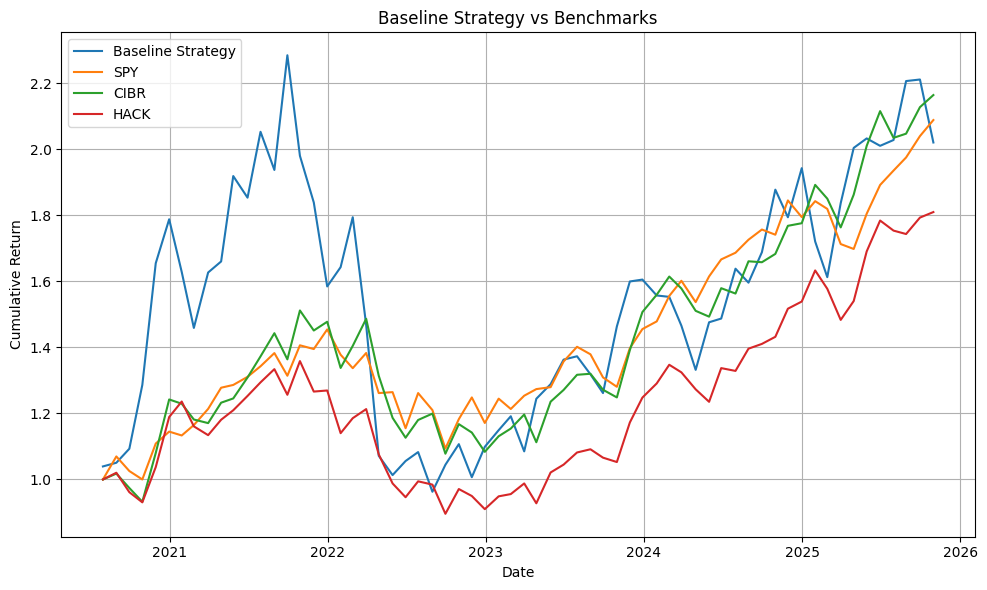

In [61]:
plt.figure(figsize=(10, 6))

plt.plot(bench_df["date"], bench_df["cum_return"], label="Baseline Strategy")
plt.plot(bench_df["date"], bench_df["spy_cum"], label="SPY")
plt.plot(bench_df["date"], bench_df["cibr_cum"], label="CIBR")
plt.plot(bench_df["date"], bench_df["hack_cum"], label="HACK")

plt.title("Baseline Strategy vs Benchmarks")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(chart_path / "baseline_vs_benchmarks.png")
plt.show()

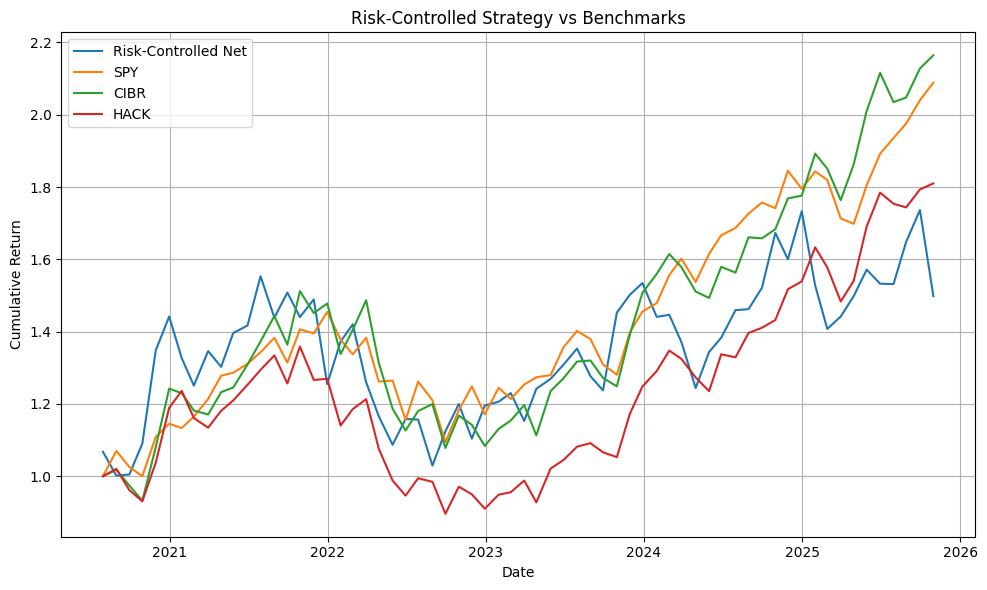

In [62]:
monthly_rc["month"] = monthly_rc["date"].dt.to_period("M").astype(str)

rc_bench = monthly_rc.copy()

rc_bench = rc_bench.merge(
    spy_month[["month", "spy_cum"]],
    on="month",
    how="left"
)

rc_bench = rc_bench.merge(
    cibr_month[["month", "cibr_cum"]],
    on="month",
    how="left"
)

rc_bench = rc_bench.merge(
    hack_month[["month", "hack_cum"]],
    on="month",
    how="left"
)

plt.figure(figsize=(10, 6))

plt.plot(rc_bench["date"], rc_bench["net_cum_return"], label="Risk-Controlled Net")
plt.plot(rc_bench["date"], rc_bench["spy_cum"], label="SPY")
plt.plot(rc_bench["date"], rc_bench["cibr_cum"], label="CIBR")
plt.plot(rc_bench["date"], rc_bench["hack_cum"], label="HACK")

plt.title("Risk-Controlled Strategy vs Benchmarks")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(chart_path / "risk_controlled_vs_benchmarks.png")
plt.show()

In [63]:
baseline_rolling_sharpe = (
    monthly_ret["strategy_ret"].rolling(12).mean() /
    monthly_ret["strategy_ret"].rolling(12).std()
) * np.sqrt(12)

In [64]:
rc_rolling_sharpe = (
    monthly_rc["net_ret"].rolling(12).mean() /
    monthly_rc["net_ret"].rolling(12).std()
) * np.sqrt(12)

In [65]:
opt_rolling_sharpe = (
    monthly_opt["opt_net_ret"].rolling(12).mean() /
    monthly_opt["opt_net_ret"].rolling(12).std()
) * np.sqrt(12)

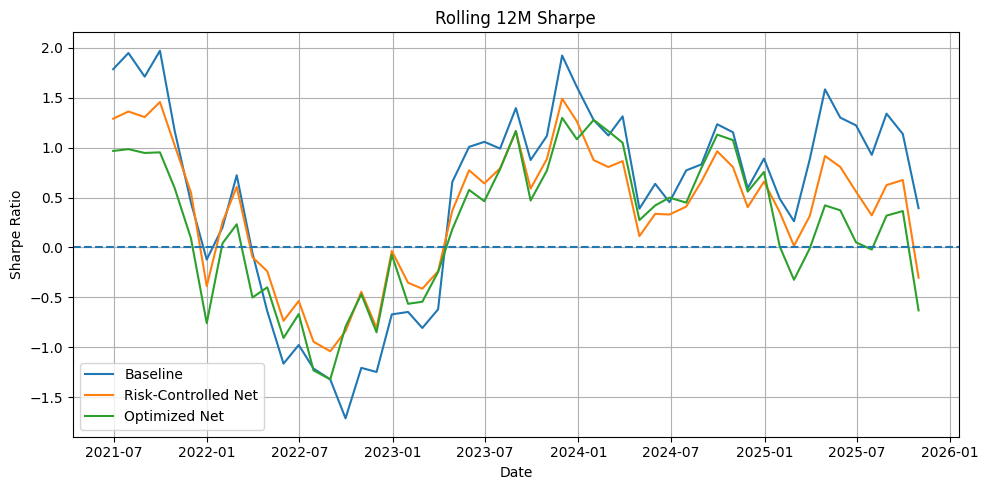

In [66]:
plt.figure(figsize=(10, 5))

plt.plot(monthly_ret["date"], baseline_rolling_sharpe, label="Baseline")
plt.plot(monthly_rc["date"], rc_rolling_sharpe, label="Risk-Controlled Net")
plt.plot(monthly_opt["date"], opt_rolling_sharpe, label="Optimized Net")

plt.axhline(0, linestyle="--")
plt.title("Rolling 12M Sharpe")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(chart_path / "rolling_12m_sharpe.png")
plt.show()

In [67]:
benchmark_summary = pd.DataFrame({
    "series": ["Baseline", "Risk-Controlled Net", "Optimized Net", "SPY", "CIBR", "HACK"],
    "final_cum_return": [
        monthly_ret["cum_return"].iloc[-1],
        monthly_rc["net_cum_return"].iloc[-1],
        monthly_opt["opt_net_cum_return"].iloc[-1],
        spy_month["spy_cum"].iloc[-1],
        cibr_month["cibr_cum"].iloc[-1],
        hack_month["hack_cum"].iloc[-1]
    ]
})

benchmark_summary

,series,final_cum_return
0,Baseline,2.020864
1,Risk-Controlled Net,1.498317
2,Optimized Net,1.154741
3,SPY,2.054912
4,CIBR,2.110302
5,HACK,1.768182


In [68]:
benchmark_summary.to_csv(table_path / "benchmark_summary.csv", index=False)
print("Saved benchmark summary.")

Saved benchmark summary.


## Top-K Sensitivity Analysis

In [69]:
def backtest_topk_equal_weight(pred_df, top_n):
    temp = pred_df.sort_values(["date", "pred_ret"], ascending=[True, False]).groupby("date").head(top_n).copy()
    temp["weight"] = 1 / top_n
    temp["strategy_ret"] = temp["weight"] * temp["fwd_ret_1m"]

    monthly = temp.groupby("date").agg(
        strategy_ret=("strategy_ret", "sum")
    ).reset_index()

    monthly["cum_return"] = (1 + monthly["strategy_ret"]).cumprod()
    return monthly

In [71]:
topk_results = {}

for k in [3, 5, 8]:
    res = backtest_topk_equal_weight(pred, top_n=k)
    topk_results[k] = res

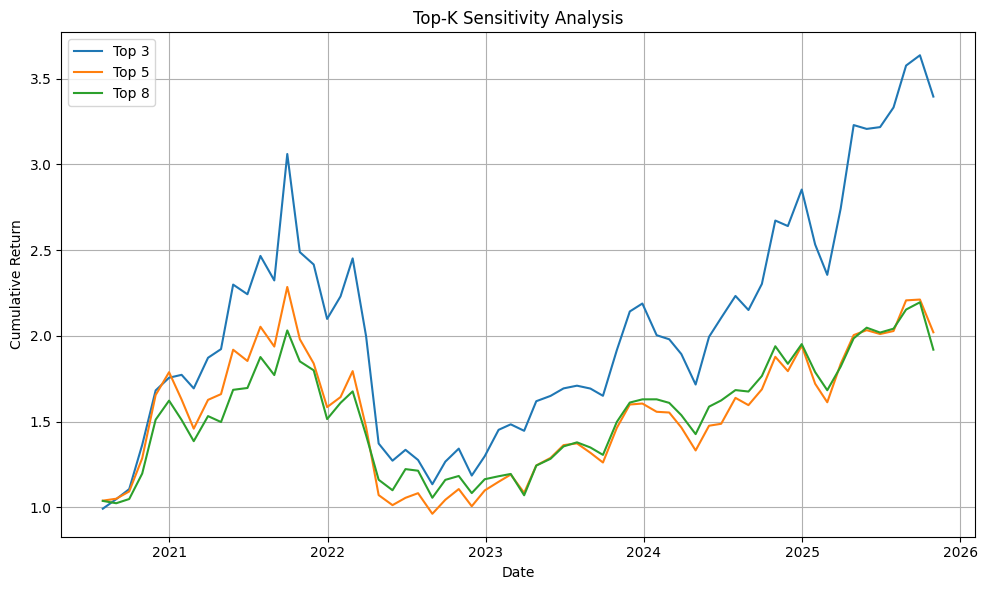

In [72]:
plt.figure(figsize=(10, 6))

for k, res in topk_results.items():
    plt.plot(res["date"], res["cum_return"], label=f"Top {k}")

plt.title("Top-K Sensitivity Analysis")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(chart_path / "topk_sensitivity.png")
plt.show()

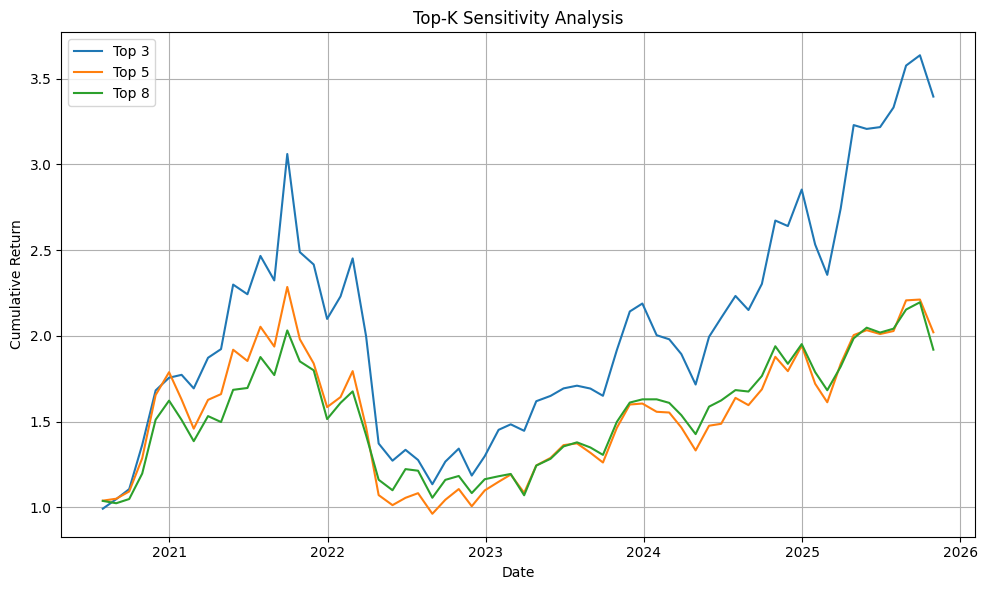

In [73]:
plt.figure(figsize=(10, 6))

for k, res in topk_results.items():
    plt.plot(res["date"], res["cum_return"], label=f"Top {k}")

plt.title("Top-K Sensitivity Analysis")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(chart_path / "topk_sensitivity.png")
plt.show()

## Long-Short Portfolio

In [74]:
top_n = 3
bottom_n = 3

long_leg = pred.sort_values(["date", "pred_ret"], ascending=[True, False]).groupby("date").head(top_n).copy()
short_leg = pred.sort_values(["date", "pred_ret"], ascending=[True, True]).groupby("date").head(bottom_n).copy()

long_leg["ls_weight"] = 1 / top_n
short_leg["ls_weight"] = -1 / bottom_n

long_leg["ls_ret"] = long_leg["ls_weight"] * long_leg["fwd_ret_1m"]
short_leg["ls_ret"] = short_leg["ls_weight"] * short_leg["fwd_ret_1m"]

long_short_portfolio = pd.concat([long_leg, short_leg], ignore_index=True)

long_short_monthly = long_short_portfolio.groupby("date").agg(
    ls_ret=("ls_ret", "sum")
).reset_index()

long_short_monthly["ls_cum_return"] = (1 + long_short_monthly["ls_ret"]).cumprod()

long_short_monthly.head()

,date,ls_ret,ls_cum_return
0,2020-07-31,-0.049396,0.950604
1,2020-08-31,0.110493,1.055639
2,2020-09-30,0.125990,1.188639
3,2020-10-30,0.036760,1.232334
4,2020-11-30,0.162973,1.433171


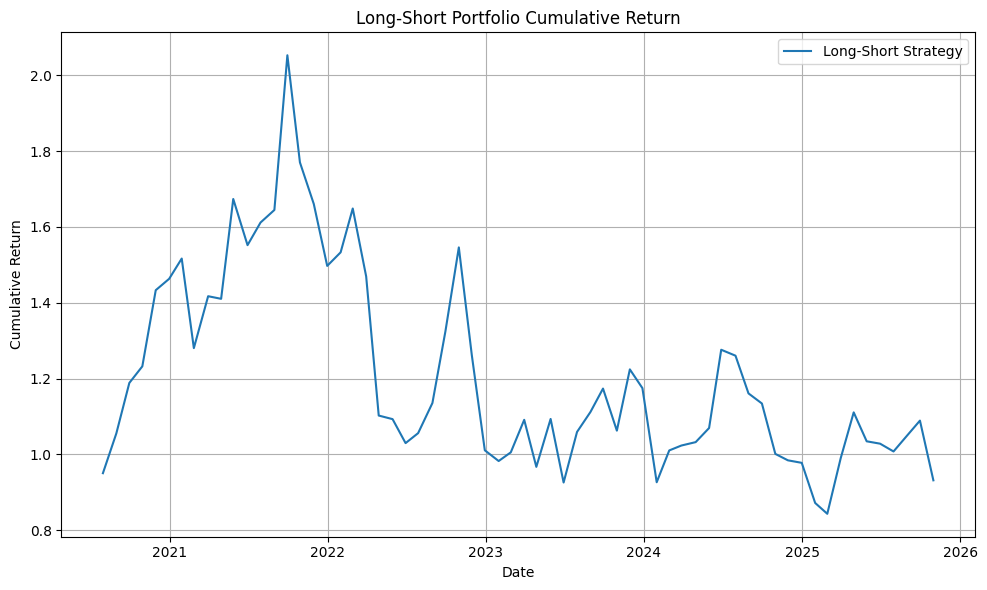

In [75]:
plt.figure(figsize=(10, 6))

plt.plot(long_short_monthly["date"], long_short_monthly["ls_cum_return"], label="Long-Short Strategy")

plt.title("Long-Short Portfolio Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(chart_path / "long_short_strategy.png")
plt.show()

In [77]:
ls_metrics = compute_metrics(long_short_monthly["ls_ret"], long_short_monthly["ls_cum_return"])

ls_summary = pd.DataFrame({
    "metric": ["Annual Return", "Annual Volatility", "Sharpe Ratio", "Sortino Ratio", "Max Drawdown"],
    "long_short": ls_metrics
})

ls_summary

,metric,long_short
0,Annual Return,0.061709
1,Annual Volatility,0.383217
2,Sharpe Ratio,0.161029
3,Sortino Ratio,0.262168
4,Max Drawdown,-0.589053


In [78]:
ls_summary.to_csv(table_path / "long_short_summary.csv", index=False)
print("Saved long-short summary.")

Saved long-short summary.


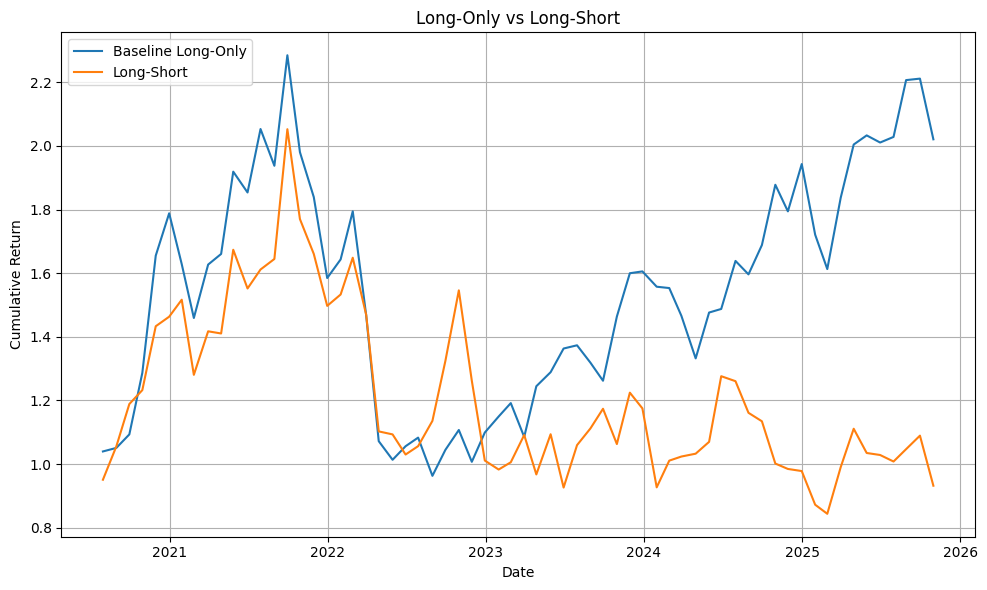

In [79]:
plt.figure(figsize=(10, 6))

plt.plot(monthly_ret["date"], monthly_ret["cum_return"], label="Baseline Long-Only")
plt.plot(long_short_monthly["date"], long_short_monthly["ls_cum_return"], label="Long-Short")

plt.title("Long-Only vs Long-Short")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(chart_path / "long_only_vs_long_short.png")
plt.show()

## Subtheme-Neutral Portfolio Construction

In [80]:
universe_df = pd.read_csv(base_path / "data" / "external" / "universe.csv")

pred_sub = pred.merge(
    universe_df[["ticker", "subtheme"]],
    on="ticker",
    how="left"
)

pred_sub.head()

,date,month,ticker,mom_1m,mom_3m,mom_6m,vol_1m,vol_3m,vol_6m,volume_ratio,fwd_ret_1m,pred_ret,subtheme
0,2020-07-31,2020-07,ZS,0.164470,0.942409,1.315030,0.029620,0.047693,0.047996,0.479028,0.103889,0.075713,cloud
1,2020-07-31,2020-07,NET,0.126997,0.822242,1.330347,0.035408,0.043279,0.048477,0.925433,-0.080730,0.068999,network_edge
2,2020-07-31,2020-07,FTNT,-0.006608,0.325474,0.198856,0.033307,0.037652,0.043687,0.504895,-0.045481,0.065197,network
3,2020-07-31,2020-07,TENB,0.125747,0.359375,0.245138,0.054156,0.035735,0.040696,3.338032,0.109343,0.058566,endpoint
4,2020-07-31,2020-07,CRWD,0.099563,0.635602,0.853004,0.037055,0.034493,0.045386,0.434706,0.110689,0.050410,endpoint


In [81]:
pred_sub = pred_sub[pred_sub["pred_ret"] > 0].copy()

# 每月最多取前8只
pred_sub = pred_sub.sort_values(["date", "pred_ret"], ascending=[True, False]).groupby("date").head(8).copy()

In [82]:
def build_subtheme_neutral_weights(group, subtheme_cap=0.40):
    group = group.copy()

    # 风险调整得分
    group["score"] = group["pred_ret"] / group["vol_3m"].replace(0, np.nan)
    group["score"] = group["score"].replace([np.inf, -np.inf], np.nan)
    group["score"] = group["score"].fillna(0).clip(lower=0)

    subthemes = group["subtheme"].dropna().unique().tolist()

    if len(subthemes) == 0:
        group["sub_w"] = 1 / len(group)
        return group

    # 每个主题先平分预算，但 capped
    raw_sub_alloc = 1 / len(subthemes)
    sub_alloc = min(raw_sub_alloc, subtheme_cap)

    # 如果 cap 后总和不为1，重新归一化
    alloc_map = {s: sub_alloc for s in subthemes}
    total_alloc = sum(alloc_map.values())
    alloc_map = {k: v / total_alloc for k, v in alloc_map.items()}

    weights = []

    for s in subthemes:
        sub = group[group["subtheme"] == s].copy()
        alloc = alloc_map[s]

        if sub["score"].sum() <= 0:
            sub["sub_w"] = alloc / len(sub)
        else:
            sub["sub_w"] = alloc * sub["score"] / sub["score"].sum()

        weights.append(sub)

    out = pd.concat(weights, ignore_index=True)
    return out

In [83]:
portfolio_sub = pred_sub.groupby("date", group_keys=False).apply(build_subtheme_neutral_weights).reset_index(drop=True)

portfolio_sub["sub_ret"] = portfolio_sub["sub_w"] * portfolio_sub["fwd_ret_1m"]

monthly_sub = portfolio_sub.groupby("date").agg(
    sub_ret=("sub_ret", "sum")
).reset_index()

monthly_sub["sub_cum_return"] = (1 + monthly_sub["sub_ret"]).cumprod()

monthly_sub.head()

C:\Users\nch\AppData\Local\Temp\ipykernel_11744\127746794.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  portfolio_sub = pred_sub.groupby("date", group_keys=False).apply(build_subtheme_neutral_weights).reset_index(drop=True)


,date,sub_ret,sub_cum_return
0,2020-07-31,0.028019,1.028019
1,2020-08-31,-0.005373,1.022495
2,2020-09-30,0.038755,1.062122
3,2020-10-30,0.155501,1.227283
4,2020-11-30,0.240474,1.522413


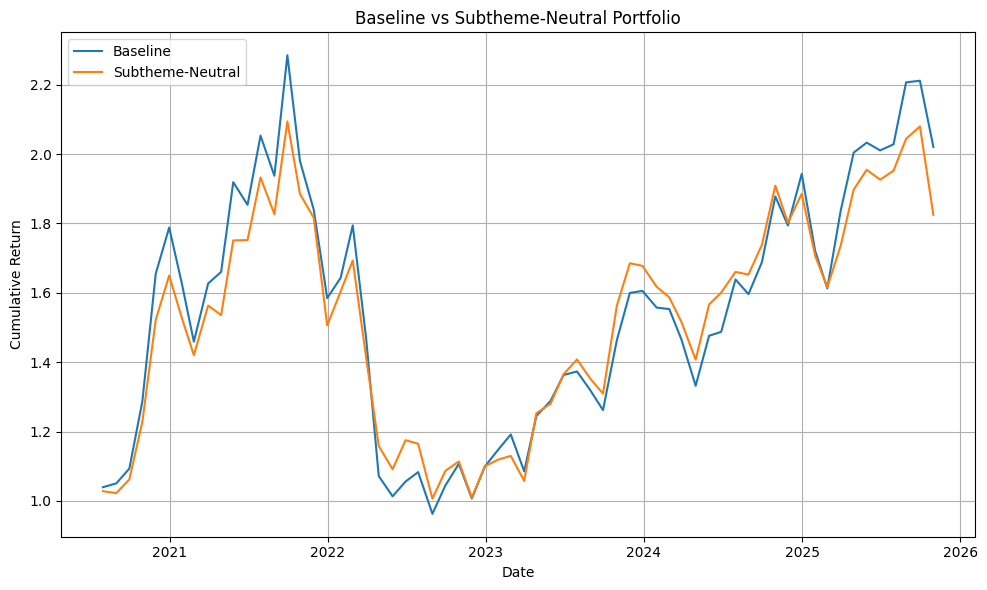

In [84]:
plt.figure(figsize=(10, 6))

plt.plot(monthly_ret["date"], monthly_ret["cum_return"], label="Baseline")
plt.plot(monthly_sub["date"], monthly_sub["sub_cum_return"], label="Subtheme-Neutral")

plt.title("Baseline vs Subtheme-Neutral Portfolio")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(chart_path / "subtheme_neutral_strategy.png")
plt.show()

In [85]:
sub_metrics = compute_metrics(monthly_sub["sub_ret"], monthly_sub["sub_cum_return"])

sub_summary = pd.DataFrame({
    "metric": ["Annual Return", "Annual Volatility", "Sharpe Ratio", "Sortino Ratio", "Max Drawdown"],
    "subtheme_neutral": sub_metrics
})

sub_summary

,metric,subtheme_neutral
0,Annual Return,0.171198
1,Annual Volatility,0.305942
2,Sharpe Ratio,0.559578
3,Sortino Ratio,0.963422
4,Max Drawdown,-0.519374


In [86]:
sub_summary.to_csv(table_path / "subtheme_neutral_summary.csv", index=False)
print("Saved subtheme-neutral summary.")

Saved subtheme-neutral summary.
